# EM2050: Computational Methods
## Practical 4: Numerical Solution of Oscillatory Systems

### Part A: Forward Euler Method

#### **A.1 Numerical Scheme Derivation**
The Forward Euler method approximates derivatives using the current time step $t_k$:
$$\frac{u_{k+1} - u_k}{\Delta t} = v_k \implies u_{k+1} = u_k + \Delta t \, v_k$$
$$\frac{v_{k+1} - v_k}{\Delta t} = -\omega^2 u_k \implies v_{k+1} = v_k - \Delta t \, \omega^2 u_k$$

#### **A.2 Hand Calculations (First Two Time Steps)**
Given values: $X_0 = 2$, $\omega = 2$, $P = \pi \approx 3.1416$, and $\Delta t = \frac{P}{20} \approx 0.1571$.
* **Step 1 ($k=0 \to k=1$):**
  * $u_1 = u_0 + \Delta t \, v_0 = 2 + (0.1571)(0) = 2$
  * $v_1 = v_0 - \Delta t \, \omega^2 u_0 = 0 - (0.1571)(4)(2) \approx -1.2566$
* **Step 2 ($k=1 \to k=2$):**
  * $u_2 = u_1 + \Delta t \, v_1 = 2 + (0.1571)(-1.2566) \approx 1.8026$
  * $v_2 = v_1 - \Delta t \, \omega^2 u_1 = -1.2566 - (0.1571)(4)(2) \approx -2.5133$

<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_431/2863725696.py:32: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(t, u, label='Forward Euler ($\Delta t = P/20$)', color='crimson')


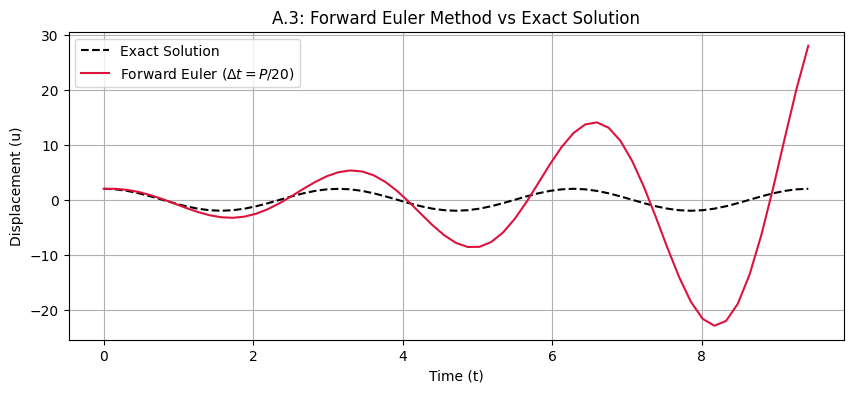

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter definitions
X0 = 2
omega = 2
P = 2 * np.pi / omega
T = 3 * P
dt = P / 20
num_steps = int(T / dt)

# Setup tracking arrays
t = np.linspace(0, T, num_steps + 1)
u = np.zeros(num_steps + 1)
v = np.zeros(num_steps + 1)

# Initial conditions
u[0] = X0
v[0] = 0

# Forward Euler Loop
for k in range(num_steps):
    u[k+1] = u[k] + dt * v[k]
    v[k+1] = v[k] - dt * (omega**2) * u[k]

# Exact Analytical Solution
u_exact = X0 * np.cos(omega * t)

# Plotting
plt.figure(figsize=(10, 4))
plt.plot(t, u_exact, label='Exact Solution', linestyle='--', color='black')
plt.plot(t, u, label='Forward Euler ($\Delta t = P/20$)', color='crimson')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.title('A.3: Forward Euler Method vs Exact Solution')
plt.legend()
plt.grid(True)
plt.show()

#### **A.3 Observations**
The numerical solution roughly tracks the frequency of the exact cosine wave, but its peak amplitude systematically grows with every wave cycle, physically diverging from the true bounded system[cite: 1].

#### **A.4 Step Size Verification ($\Delta t = \frac{P}{40}, \frac{P}{160}, \frac{P}{2000}$)**
Run the cell below to witness how changing the time step alters the accuracy of our system.

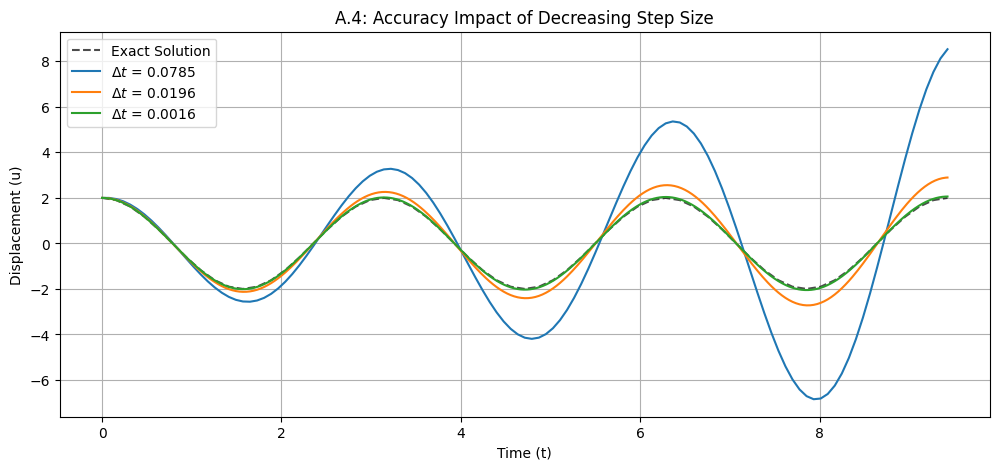

In [4]:
step_sizes = [P/40, P/160, P/2000]

plt.figure(figsize=(12, 5))
plt.plot(t, u_exact, label='Exact Solution', linestyle='--', color='black', alpha=0.7)

for step in step_sizes:
    n_steps = int(T / step)
    t_test = np.linspace(0, T, n_steps + 1)
    u_test = np.zeros(n_steps + 1)
    v_test = np.zeros(n_steps + 1)
    u_test[0], v_test[0] = X0, 0

    for k in range(n_steps):
        u_test[k+1] = u_test[k] + step * v_test[k]
        v_test[k+1] = v_test[k] - step * (omega**2) * u_test[k]

    plt.plot(t_test, u_test, label=r'$\Delta t$ = ' + f'{step:.4f}')

plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.title('A.4: Accuracy Impact of Decreasing Step Size')
plt.legend()
plt.grid(True)
plt.show()

* **Commentary on Step Size:** As $\Delta t$ gets smaller, the numerical result moves significantly closer to the exact solution[cite: 1]. This matches the theoretical global truncation error of $\mathcal{O}(\Delta t)$[cite: 1]. However, reducing the step size only delays the inevitable amplitude growth; it does not eliminate it[cite: 1].

#### **A.5 Long-Term Simulation ($T = 50P, \Delta t = \frac{P}{2000}$)**
Let us project the simulation further down the timeline to check the bounds of the Forward Euler stability profile.

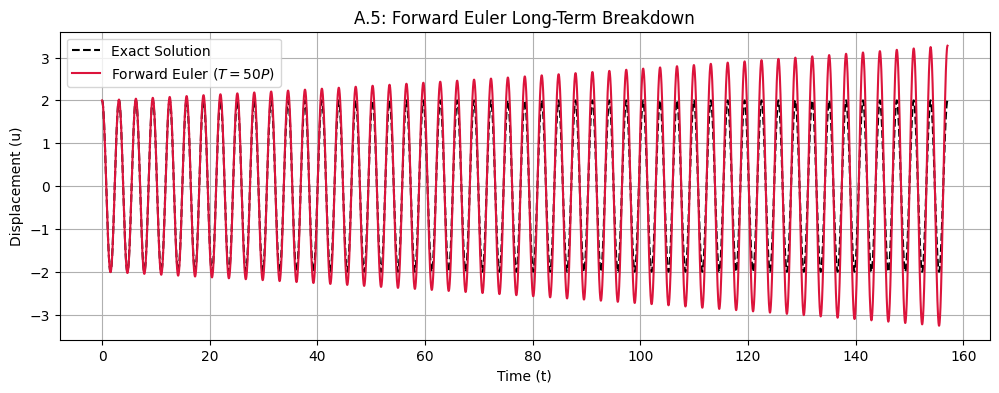

In [5]:
T_long = 50 * P
dt_long = P / 2000
num_steps_long = int(T_long / dt_long)

t_long = np.linspace(0, T_long, num_steps_long + 1)
u_long = np.zeros(num_steps_long + 1)
v_long = np.zeros(num_steps_long + 1)
u_long[0], v_long[0] = X0, 0

for k in range(num_steps_long):
    u_long[k+1] = u_long[k] + dt_long * v_long[k]
    v_long[k+1] = v_long[k] - dt_long * (omega**2) * u_long[k]

u_exact_long = X0 * np.cos(omega * t_long)

plt.figure(figsize=(12, 4))
plt.plot(t_long, u_exact_long, label='Exact Solution', linestyle='--', color='black')
plt.plot(t_long, u_long, label='Forward Euler ($T=50P$)', color='crimson')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.title('A.5: Forward Euler Long-Term Breakdown')
plt.legend()
plt.grid(True)
plt.show()

* **Long Term Observation:** Even with a high-resolution time step ($\Delta t = \frac{P}{2000}$), running the solution across a long span ($T = 50P$) demonstrates severe **artificial amplitude growth**[cite: 1]. This indicates that the Forward Euler scheme introduces unphysical numerical energy, rendering it mathematically unstable for tracking periodic orbits over long durations[cite: 1].

---
### Part B: A Modified Euler Scheme

#### **B.1 Scheme Derivation**
Reordering the equations:
1. $v' = -\omega^2 u$[cite: 1]
2. $u' = v$[cite: 1]

Applying Forward Euler to velocity and Backward Euler to position yields our updated semi-implicit tracking scheme[cite: 1]:
$$v_{k+1} = v_k - \Delta t \, \omega^2 u_k$$
$$u_{k+1} = u_k + \Delta t \, v_{k+1}$$

#### **B.2 Hand Calculations (First Two Time Steps)**
Using identical starting metrics ($u_0 = 2, v_0 = 0, \Delta t \approx 0.1571$):
* **Step 1 ($k=0 \to k=1$):**
  * $v_1 = v_0 - \Delta t \, \omega^2 u_0 = 0 - (0.1571)(4)(2) \approx -1.2566$
  * $u_1 = u_0 + \Delta t \, v_1 = 2 + (0.1571)(-1.2566) \approx 1.8026$
* **Step 2 ($k=1 \to k=2$):**
  * $v_2 = v_1 - \Delta t \, \omega^2 u_1 = -1.2566 - (0.1571)(4)(1.8026) \approx -2.3893$
  * $u_2 = u_1 + \Delta t \, v_2 = 1.8026 + (0.1571)(-2.3893) \approx 1.4273$

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_431/4131746212.py:14: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(t, u_mod, label='Modified Euler ($\Delta t = P/20$)', color='royalblue')


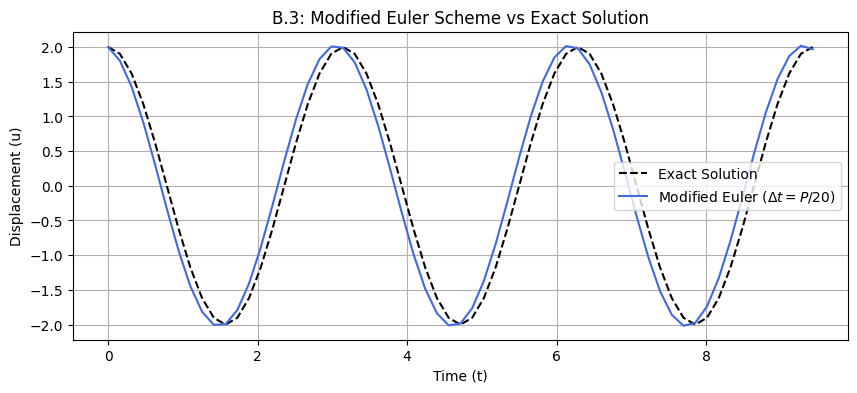

In [6]:
# Initialize arrays for Modified Scheme
u_mod = np.zeros(num_steps + 1)
v_mod = np.zeros(num_steps + 1)
u_mod[0], v_mod[0] = X0, 0

# Modified Euler Loop
for k in range(num_steps):
    v_mod[k+1] = v_mod[k] - dt * (omega**2) * u_mod[k]
    u_mod[k+1] = u_mod[k] + dt * v_mod[k+1]

# Plotting B.3 Comparison
plt.figure(figsize=(10, 4))
plt.plot(t, u_exact, label='Exact Solution', linestyle='--', color='black')
plt.plot(t, u_mod, label='Modified Euler ($\Delta t = P/20$)', color='royalblue')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.title('B.3: Modified Euler Scheme vs Exact Solution')
plt.legend()
plt.grid(True)
plt.show()

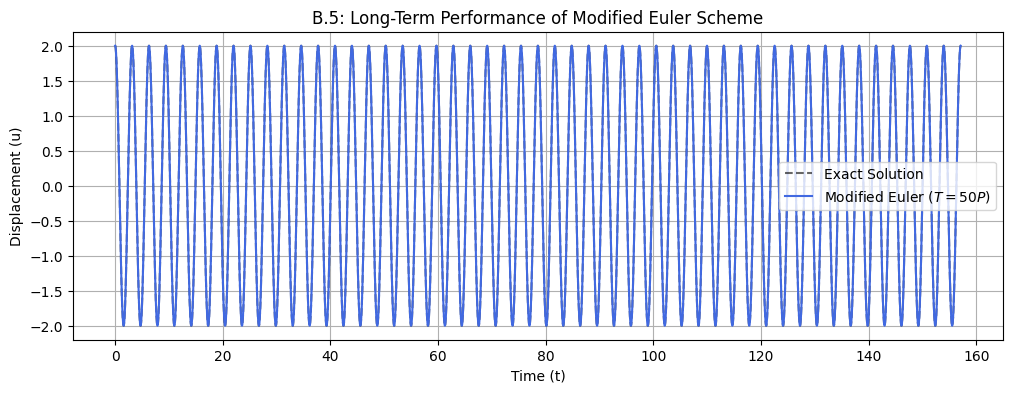

In [7]:
# B.4 & B.5 Long Term Modified Euler Verification
u_mod_long = np.zeros(num_steps_long + 1)
v_mod_long = np.zeros(num_steps_long + 1)
u_mod_long[0], v_mod_long[0] = X0, 0

for k in range(num_steps_long):
    v_mod_long[k+1] = v_mod_long[k] - dt_long * (omega**2) * u_mod_long[k]
    u_mod_long[k+1] = u_mod_long[k] + dt_long * v_mod_long[k+1]

plt.figure(figsize=(12, 4))
plt.plot(t_long, u_exact_long, label='Exact Solution', linestyle='--', color='black', alpha=0.6)
plt.plot(t_long, u_mod_long, label='Modified Euler ($T=50P$)', color='royalblue')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (u)')
plt.title('B.5: Long-Term Performance of Modified Euler Scheme')
plt.legend()
plt.grid(True)
plt.show()

#### **B.4 & B.5 Observations**
Unlike the regular Euler method, the Modified Euler scheme shows excellent structural preservation[cite: 1]. Even over long simulated spaces ($T = 50P$), the amplitude remains completely bounded and shows no signs of artificial explosive growth or decay[cite: 1].

---

### Part C: Comparison of the Two Schemes

Based on the experiments above, we can draw the following formal conclusions[cite: 1]:

| Question Asked | Analytical Conclusion |
| :--- | :--- |
| **C.1 Which method gives a better approximation for short time intervals?** | **Modified Euler.** It bounds energy and tracks the profile closer from the initial steps[cite: 1]. |
| **C.2 Which method gives better long-term behaviour?** | **Modified Euler.** The standard Forward Euler method completely fails over long periods[cite: 1]. |
| **C.3 What happens to the amplitude of the oscillations in the Forward Euler method?** | The amplitude suffers from **unphysical, artificial numerical growth**[cite: 1]. |
| **C.4 What happens to the amplitude in the modified method?** | The amplitude remains **perfectly stable, bounded, and oscilattory**[cite: 1]. |
| **C.5 Based on your observations, which method is more suitable for oscillatory systems?** | The **Modified Euler method** (Symplectic Euler) is the superior, physically accurate option for conservative mechanical systems[cite: 1]. |